**Modeling ecommerce data using 3 models - Logistic Regression, Random Forest and XGBoost**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42


## 1. Load and inspect the dataset


In [2]:
df = pd.read_csv("/content/online_shoppers_preprocessed.csv")

print("Shape:", df.shape)
display(df.head())
print("\nTarget distribution:")
print(df["Revenue"].value_counts())
print("\nPurchase rate:", df["Revenue"].mean())


Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,0



Target distribution:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Purchase rate: 0.15474452554744525


In [3]:
X = df.drop("Revenue", axis=1).copy()
y = df["Revenue"].astype(int).copy()

# Preserve an untouched 20% test set.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Use only the original training portion to create train/validation data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print(f"Train:      {X_train.shape[0]:,}")
print(f"Validation: {X_val.shape[0]:,}")
print(f"Test:       {X_test.shape[0]:,}")

print("\nClass rates:")
print("Train:      ", round(y_train.mean(), 4))
print("Validation: ", round(y_val.mean(), 4))
print("Test:       ", round(y_test.mean(), 4))


Train:      7,891
Validation: 1,973
Test:       2,466

Class rates:
Train:       0.1547
Validation:  0.1546
Test:        0.1549


## 2. Preprocessing




In [4]:
# Categorical variables in the Online Shoppers Intention dataset.
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop",
)

# Fit preprocessing ONLY on training data.
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Transformed feature count:", len(feature_names))


Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical features: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Transformed feature count: 75


## 3. Model definitions


In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}


## 4. Train models and select thresholds on validation data

The threshold is selected by maximizing F1 on the validation set. **The test labels are not used for threshold selection.**



In [6]:
def find_best_f1_threshold(y_true, probabilities, low=0.05, high=0.95, n=181):
    thresholds = np.linspace(low, high, n)
    f1_values = [
        f1_score(y_true, (probabilities >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_values))
    return float(thresholds[best_idx]), float(f1_values[best_idx])

results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_p, y_train)

    val_proba = model.predict_proba(X_val_p)[:, 1]
    threshold, val_f1 = find_best_f1_threshold(y_val, val_proba)

    test_proba = model.predict_proba(X_test_p)[:, 1]
    test_pred = (test_proba >= threshold).astype(int)

    results[name] = {
        "threshold": threshold,
        "validation_f1": val_f1,
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_average_precision": average_precision_score(y_test, test_proba),
    }

    fitted_models[name] = {
        "model": model,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "test_pred": test_pred,
    }

results_df = pd.DataFrame(results).T
display(results_df.round(4))


,threshold,validation_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision
Logistic Regression,0.650,0.6571,0.8796,0.6087,0.6230,0.6158,0.8914,0.6222
Random Forest,0.310,0.6944,0.8893,0.6253,0.7120,0.6659,0.9173,0.7219
XGBoost,0.605,0.7009,0.8856,0.6220,0.6675,0.6439,0.9192,0.7192


## 5. Final test-set reports


In [7]:
for name, info in fitted_models.items():
    print("=" * 80)
    print(name)
    print(f"Locked validation-selected threshold: {results[name]['threshold']:.3f}")
    print(f"Test ROC-AUC: {results[name]['test_roc_auc']:.4f}")
    print(f"Test Average Precision: {results[name]['test_average_precision']:.4f}")
    print(classification_report(
        y_test,
        info["test_pred"],
        target_names=["No Purchase", "Purchase"],
        digits=4,
        zero_division=0,
    ))


Logistic Regression
Locked validation-selected threshold: 0.650
Test ROC-AUC: 0.8914
Test Average Precision: 0.6222
              precision    recall  f1-score   support

 No Purchase     0.9306    0.9266    0.9286      2084
    Purchase     0.6087    0.6230    0.6158       382

    accuracy                         0.8796      2466
   macro avg     0.7696    0.7748    0.7722      2466
weighted avg     0.8807    0.8796    0.8801      2466

Random Forest
Locked validation-selected threshold: 0.310
Test ROC-AUC: 0.9173
Test Average Precision: 0.7219
              precision    recall  f1-score   support

 No Purchase     0.9458    0.9218    0.9337      2084
    Purchase     0.6253    0.7120    0.6659       382

    accuracy                         0.8893      2466
   macro avg     0.7856    0.8169    0.7998      2466
weighted avg     0.8962    0.8893    0.8922      2466

XGBoost
Locked validation-selected threshold: 0.605
Test ROC-AUC: 0.9192
Test Average Precision: 0.7192
              pr

## 6. ROC curves


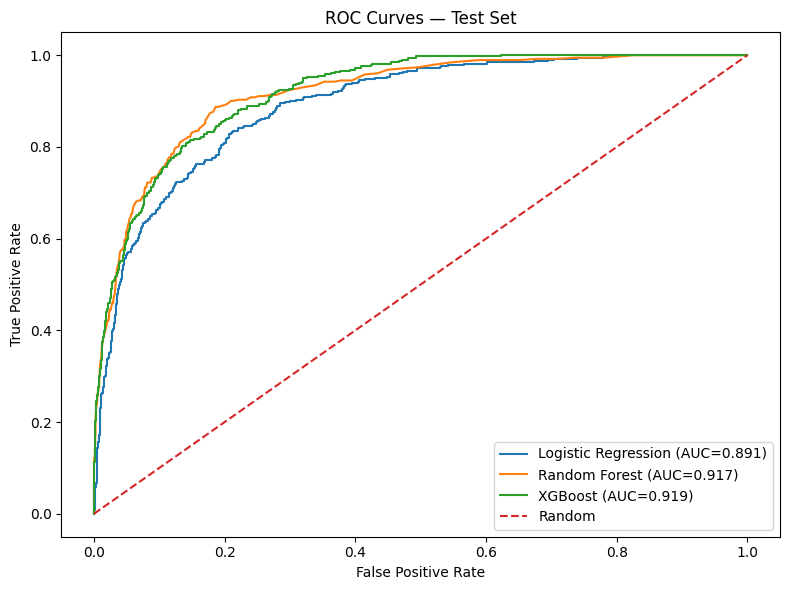

In [8]:
plt.figure(figsize=(8, 6))

for name, info in fitted_models.items():
    fpr, tpr, _ = roc_curve(y_test, info["test_proba"])
    auc = results[name]["test_roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Precision–recall curves


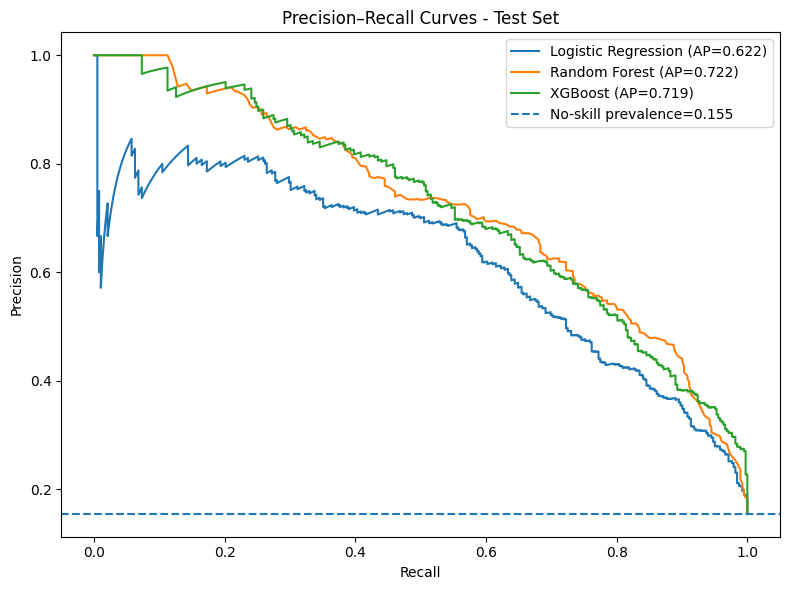

In [9]:
plt.figure(figsize=(8, 6))

for name, info in fitted_models.items():
    precision, recall, _ = precision_recall_curve(y_test, info["test_proba"])
    ap = results[name]["test_average_precision"]
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.axhline(y_test.mean(), linestyle="--", label=f"No-skill prevalence={y_test.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - Test Set")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Confusion matrices at locked thresholds


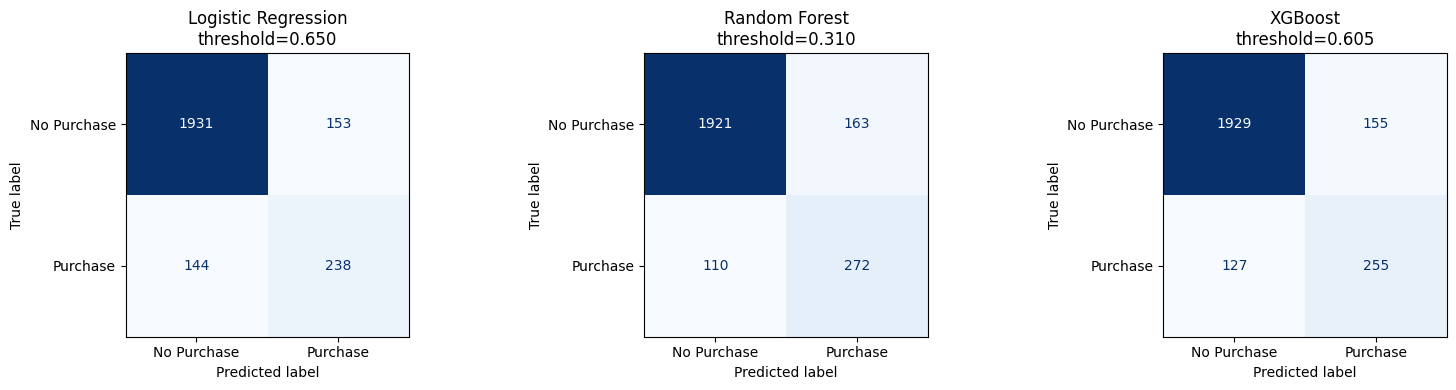

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, info) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, info["test_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Purchase", "Purchase"],
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"{name}\n"
        f"threshold={results[name]['threshold']:.3f}"
    )

plt.tight_layout()
plt.show()


## 9. XGBoost feature importance


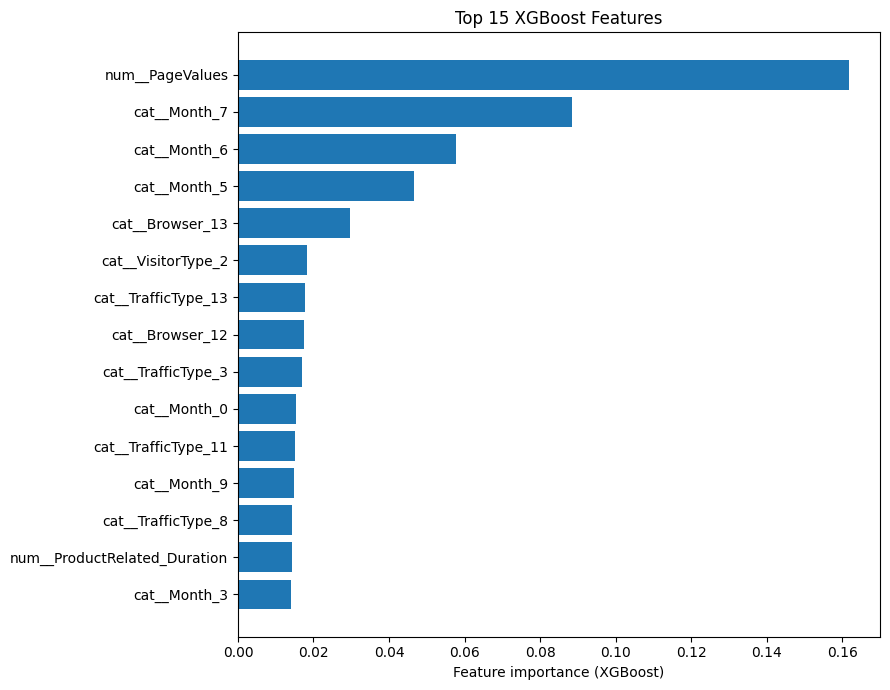

,feature,importance
8,num__PageValues,0.161922
17,cat__Month_7,0.088551
16,cat__Month_6,0.057728
15,cat__Month_5,0.046510
40,cat__Browser_13,0.029754
72,cat__VisitorType_2,0.018386
62,cat__TrafficType_13,0.017778
39,cat__Browser_12,0.017587
52,cat__TrafficType_3,0.016895
10,cat__Month_0,0.015313


In [11]:
xgb_model = fitted_models["XGBoost"]["model"]

importances_xgb = xgb_model.feature_importances_
order = np.argsort(importances_xgb)[::-1][:15]

plt.figure(figsize=(9, 7))
plt.barh(
    range(len(order)),
    importances_xgb[order][::-1],
)
plt.yticks(
    range(len(order)),
    feature_names[order][::-1],
)
plt.xlabel("Feature importance (XGBoost)")
plt.title("Top 15 XGBoost Features")
plt.tight_layout()
plt.show()

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances_xgb,
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance_df.head(15))


## 10. Model comparison

### Interpretation

- **ROC-AUC** evaluates ranking performance across all probability thresholds.
- **Average Precision (AP)** is particularly informative for this imbalanced purchase-prediction problem.
- **Precision, recall and F1** depend on the operating threshold.
- The reported test metrics use thresholds selected **only from validation data**.
- The test set is not used for model or threshold selection.

A small difference in ROC-AUC between models should not automatically be interpreted as a statistically meaningful difference. For stronger claims, use repeated stratified cross-validation and confidence intervals or paired statistical comparisons.


In [12]:
summary = results_df[
    [
        "threshold",
        "validation_f1",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_roc_auc",
        "test_average_precision",
    ]
].copy()

summary.columns = [
    "Locked threshold",
    "Validation F1",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Test ROC-AUC",
    "Test AP",
]

display(summary.round(4))


,Locked threshold,Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test AP
Logistic Regression,0.650,0.6571,0.8796,0.6087,0.6230,0.6158,0.8914,0.6222
Random Forest,0.310,0.6944,0.8893,0.6253,0.7120,0.6659,0.9173,0.7219
XGBoost,0.605,0.7009,0.8856,0.6220,0.6675,0.6439,0.9192,0.7192


## 11. Methodological checks

### Corrected leakage control
The test set is used only after the models and thresholds have been fixed. No test labels are used to select a threshold.

### Remaining limitation
This notebook still uses one fixed train/validation/test split. The reported numbers therefore represent performance on this particular split.

### Important interpretation note
XGBoost feature importance indicates how the fitted model uses variables for prediction. It is **not causal evidence** that a variable causes a purchase.

### Reproducibility
The random state is fixed at 42 for the data splits and tree-based models.
